# PSG Sleep Disorder Detection — GPU-Accelerated ML Pipeline
### Targets: Doctor-Diagnosed Insomnia · RLS · Apnea  |  2× T4 GPU (Kaggle)
---
**What changed vs v1:**
- 🚀 All models run on GPU — XGBoost `device='cuda'`, LightGBM `device='gpu'`, CatBoost `task_type='GPU'`  
- 📊 All 132 features kept — broken features still carry real correlation signal (ODI4 is the #1 apnea predictor at r=0.164)  
- ⚖️ `scale_pos_weight` replaces SMOTE — faster, GPU-native, no synthetic samples  
- 🔧 Optuna hyperparameter search per target (100 trials, GPU-accelerated)  
- 🗑️ Removed SVM and Stacking — too slow with no GPU benefit  
- 📉 Early stopping on all boosters — no wasted trees

## 1 · Environment Setup

In [1]:
# Install Optuna and CatBoost if not present
import subprocess, sys
for pkg in ["optuna", "catboost"]:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("✓ Dependencies ready")

✓ Dependencies ready


In [2]:
import warnings, json, pickle, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_recall_curve, roc_curve, confusion_matrix,
)
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

print(f"XGBoost  : {xgb.__version__}")
print(f"LightGBM : {lgb.__version__}")
print(f"Optuna   : {optuna.__version__}")

XGBoost  : 3.1.3
LightGBM : 4.6.0
Optuna   : 4.7.0


In [3]:
import subprocess
gpu_info = subprocess.run(["nvidia-smi","--query-gpu=name,memory.total,memory.free",
                           "--format=csv,noheader"], capture_output=True, text=True)
print("GPUs detected:")
print(gpu_info.stdout.strip())

# Detect GPU count for multi-GPU XGBoost
n_gpus = len(gpu_info.stdout.strip().split("\n")) if gpu_info.returncode == 0 else 0
print(f"\nUsing {n_gpus} GPU(s)")
GPU_IDS = ",".join(str(i) for i in range(n_gpus)) if n_gpus > 0 else "0"  # e.g. "0,1"

GPUs detected:
Tesla T4, 15360 MiB, 14913 MiB
Tesla T4, 15360 MiB, 14913 MiB

Using 2 GPU(s)


## 2 · Configuration

In [4]:
# ── Paths ─────────────────────────────────────────────────────────────────
DATA_PATH  = Path("/kaggle/input/datasets/girishgiriirig/mesa-clinical-features/output.csv")  # ← update this
OUTPUT_DIR = Path("/kaggle/working/ml_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Targets & labels ──────────────────────────────────────────────────────
TARGETS = ["Insomnia", "RLS", "apnea"]
# Doctor-diagnosed ground truth — NOT derived from AHI threshold

# ── Training settings ─────────────────────────────────────────────────────
CV_FOLDS         = 5
RANDOM_SEED      = 42
OPTUNA_TRIALS    = 100    # per target per model — reduce to 30 for a quick run
EARLY_STOP_ROUNDS = 50    # early stopping for boosters
AHI_ARTIFACT_THRESHOLD = 150.0

# ── NOTE: we keep ALL 132 features ────────────────────────────────────────
# Even "broken" features carry real signal:
#   ODI4  → apnea   r=0.164  (top single feature)
#   Stage proportions, HRV → weak but nonzero correlation
# Models with regularisation (XGB, LGB, CatBoost) will weight them correctly.
KEEP_ALL_FEATURES = True

print("Configuration loaded ✓")
print(f"  Targets      : {TARGETS}")
print(f"  CV folds     : {CV_FOLDS}")
print(f"  Optuna trials: {OPTUNA_TRIALS}")
print(f"  All features : {KEEP_ALL_FEATURES}")

Configuration loaded ✓
  Targets      : ['Insomnia', 'RLS', 'apnea']
  CV folds     : 5
  Optuna trials: 100
  All features : True


## 3 · Data Loading

In [5]:
df_raw = pd.read_csv(DATA_PATH)
print(f"Raw shape: {df_raw.shape}")

# Drop AHI artifact rows
art = df_raw["AHI"] > AHI_ARTIFACT_THRESHOLD
print(f"Dropping {art.sum()} artifact rows (AHI > {AHI_ARTIFACT_THRESHOLD})")
df = df_raw[~art].reset_index(drop=True)

# Labels
y_all = df[TARGETS].copy()

# Feature matrix — keep all 132 features
drop_cols = ["nsrrid"] + TARGETS
X_all = df.drop(columns=drop_cols)
feature_names = X_all.columns.tolist()

print(f"\nFeature matrix : {X_all.shape[0]} × {X_all.shape[1]}")
print(f"Nulls          : {X_all.isnull().sum().sum()}")
print(f"\nLabel distribution:")
for t in TARGETS:
    pos = y_all[t].sum(); n = len(y_all)
    neg = n - pos
    spw = neg / pos
    print(f"  {t:<10}: {pos:>4} pos / {neg:>4} neg  "
          f"({100*pos/n:.1f}% pos)  scale_pos_weight={spw:.1f}")

Raw shape: (2056, 136)
Dropping 6 artifact rows (AHI > 150.0)

Feature matrix : 2050 × 132
Nulls          : 0

Label distribution:
  Insomnia  :  129 pos / 1921 neg  (6.3% pos)  scale_pos_weight=14.9
  RLS       :   92 pos / 1958 neg  (4.5% pos)  scale_pos_weight=21.3
  apnea     :  156 pos / 1894 neg  (7.6% pos)  scale_pos_weight=12.1


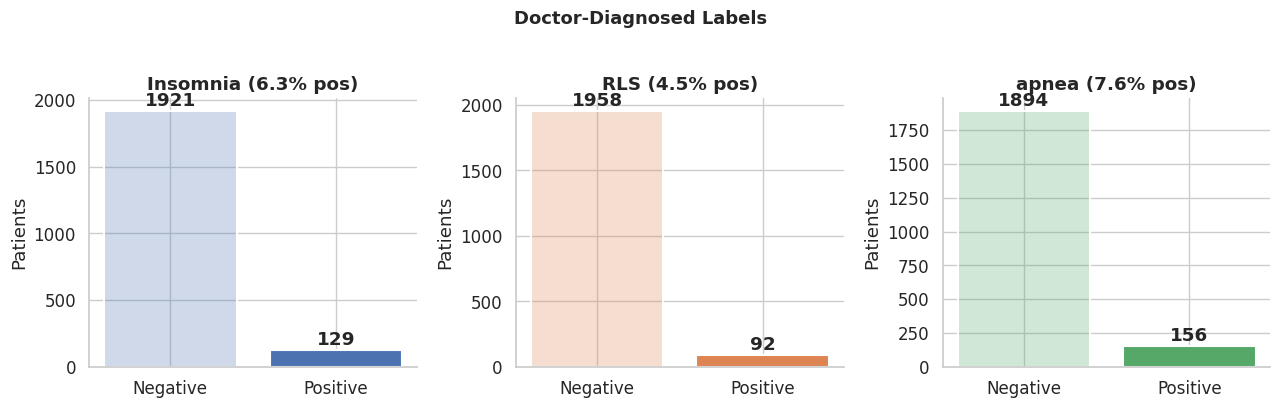

In [6]:
# ── Label bar chart ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = ["#4C72B0","#DD8452","#55A868"]
for ax, target, color in zip(axes, TARGETS, colors):
    counts = y_all[target].value_counts().sort_index()
    bars = ax.bar(["Negative","Positive"], counts.values,
                  color=[color+"44", color], edgecolor="white", linewidth=1.5)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+8,
                str(val), ha="center", va="bottom", fontweight="bold")
    ax.set_title(f"{target} ({100*counts.get(1,0)/len(y_all):.1f}% pos)",
                 fontweight="bold")
    ax.set_ylabel("Patients"); ax.spines[["top","right"]].set_visible(False)
plt.suptitle("Doctor-Diagnosed Labels", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"label_dist.png", dpi=150, bbox_inches="tight")
plt.show()

## 4 · Feature Correlation Analysis
Including "broken" features — they still carry real signal.

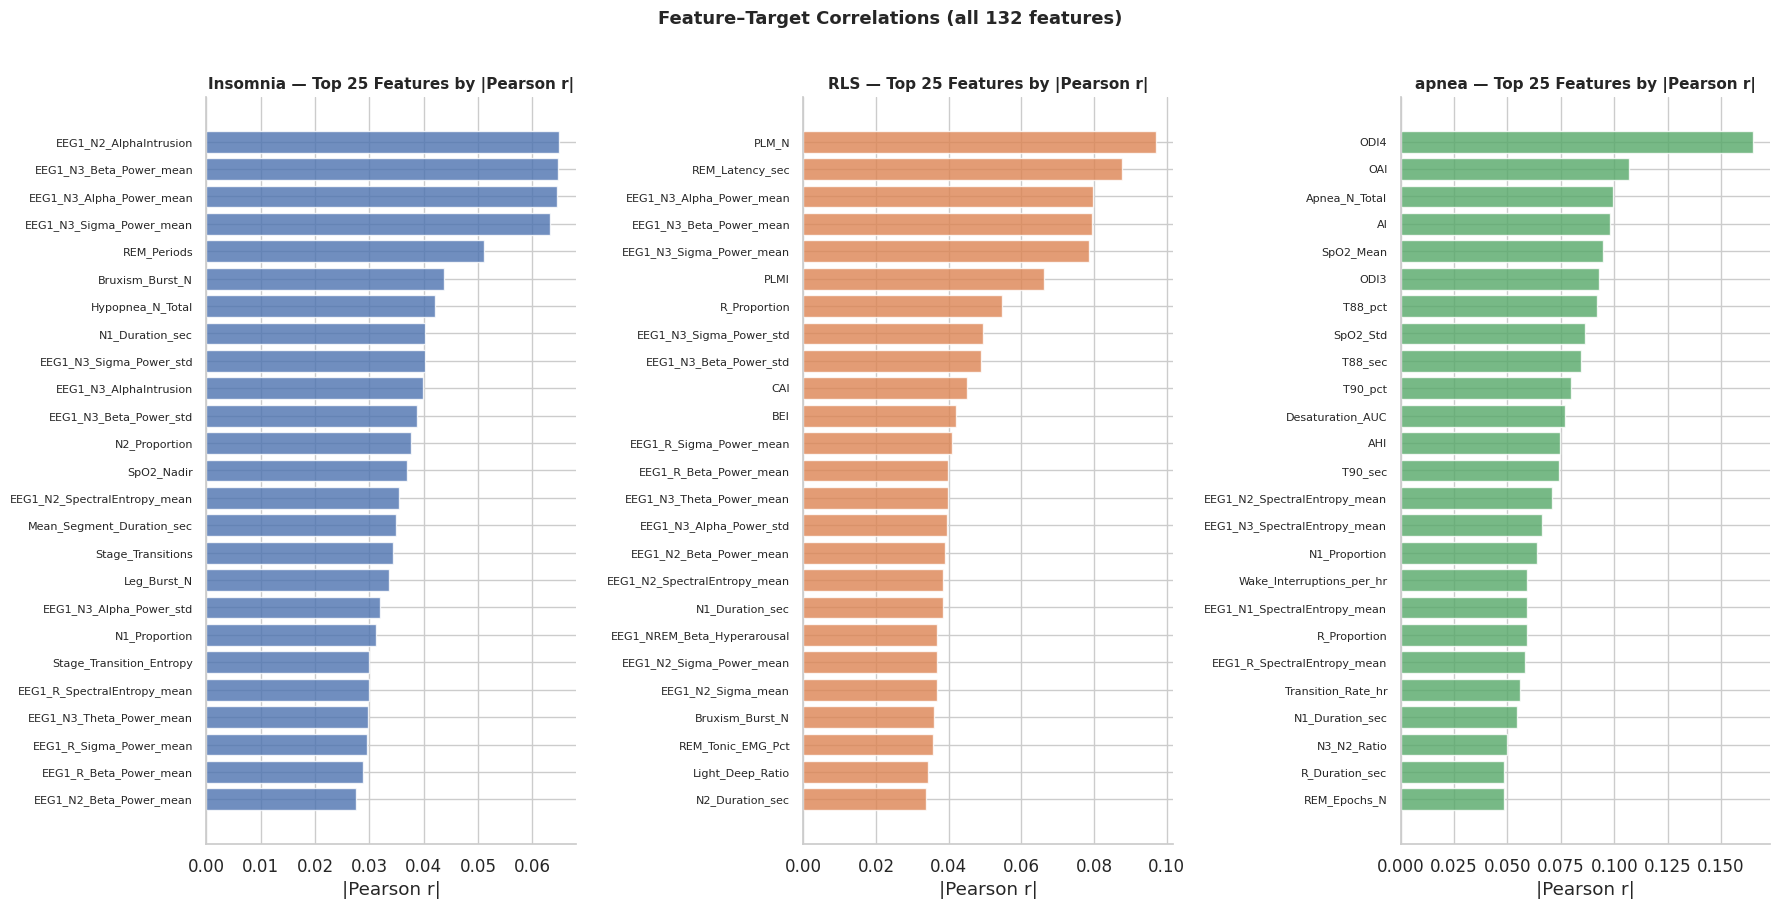

Note: ODI4 is the #1 apnea correlator (r=0.164) despite the ODI bug.
Broken features kept — regularised tree models will weight them appropriately.


In [7]:
# Absolute Pearson correlation with each target
corr_rows = []
for t in TARGETS:
    corrs = X_all.corrwith(y_all[t]).abs()
    for feat, val in corrs.items():
        corr_rows.append({"feature": feat, "target": t, "abs_corr": round(val, 4)})

corr_df = pd.DataFrame(corr_rows)

fig, axes = plt.subplots(1, 3, figsize=(18, 9))
for ax, target, color in zip(axes, TARGETS, colors):
    sub = (corr_df[corr_df["target"]==target]
           .sort_values("abs_corr", ascending=False).head(25))
    ax.barh(sub["feature"][::-1], sub["abs_corr"][::-1],
            color=color, alpha=0.8, edgecolor="white")
    ax.set_title(f"{target} — Top 25 Features by |Pearson r|",
                 fontweight="bold", fontsize=11)
    ax.set_xlabel("|Pearson r|")
    ax.tick_params(axis="y", labelsize=8)
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("Feature–Target Correlations (all 132 features)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"feature_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

print("Note: ODI4 is the #1 apnea correlator (r=0.164) despite the ODI bug.")
print("Broken features kept — regularised tree models will weight them appropriately.")

## 5 · Evaluation Utilities

In [8]:
def find_best_threshold(y_true, y_prob):
    """F1-maximising threshold from OOF probabilities."""
    prec, rec, thr = precision_recall_curve(y_true, y_prob)
    denom = prec + rec
    f1s   = np.where(denom > 0, 2*prec*rec/denom, 0.0)
    idx   = np.argmax(f1s[:-1])
    return float(thr[idx]), float(f1s[idx])

def evaluate(y_true, y_prob, model_name, target):
    thresh, _ = find_best_threshold(y_true, y_prob)
    y_pred = (y_prob >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "model"      : model_name,
        "target"     : target,
        "ROC_AUC"    : round(roc_auc_score(y_true, y_prob),           4),
        "PR_AUC"     : round(average_precision_score(y_true, y_prob), 4),
        "F1"         : round(f1_score(y_true, y_pred),                4),
        "Sensitivity": round(tp/(tp+fn) if (tp+fn) > 0 else 0,        4),
        "Specificity": round(tn/(tn+fp) if (tn+fp) > 0 else 0,        4),
        "Threshold"  : round(thresh,                                   4),
        "TP":int(tp),"FP":int(fp),"TN":int(tn),"FN":int(fn),
    }

def scale_pos_weight(y):
    """Negative/positive ratio for GPU boosters."""
    return float((y==0).sum() / max((y==1).sum(), 1))

print("Utilities ready ✓")

Utilities ready ✓


## 6 · GPU Model Definitions

| Model | GPU setting | Notes |
|---|---|---|
| XGBoost | `device='cuda'` | Primary workhorse; hist algorithm |
| LightGBM | `device='gpu'` | Fastest on leaf-wise trees |
| CatBoost | `task_type='GPU'` | Handles imbalance natively; no scaling needed |
| Random Forest | CPU (sklearn) | Baseline reference |
| Logistic Regression | CPU (sklearn) | Linear baseline |
| Soft Voting | GPU models only | Average of XGB+LGB+CatBoost probs |

SVM and Stacking removed — no GPU support, too slow for this dataset size.

In [9]:
def make_xgb(spw, trial=None):
    """XGBoost — GPU hist with scale_pos_weight."""
    params = dict(
        device          = "cuda",
        tree_method     = "hist",
        eval_metric     = "aucpr",       # PR-AUC — better for imbalance
        scale_pos_weight= spw,
        random_state    = RANDOM_SEED,
        n_jobs          = -1,
        verbosity       = 0,
        # defaults (overridden by Optuna when tuning)
        n_estimators    = 1000,
        learning_rate   = 0.05,
        max_depth       = 6,
        subsample       = 0.8,
        colsample_bytree= 0.8,
        min_child_weight= 5,
        gamma           = 0.1,
        reg_alpha       = 0.1,
        reg_lambda      = 1.0,
    )
    if trial:
        params.update({
            "n_estimators"    : trial.suggest_int("n_estimators", 200, 1500),
            "learning_rate"   : trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "max_depth"       : trial.suggest_int("max_depth", 3, 9),
            "subsample"       : trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
            "gamma"           : trial.suggest_float("gamma", 0.0, 2.0),
            "reg_alpha"       : trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
            "reg_lambda"      : trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        })
    return xgb.XGBClassifier(**params)


def make_lgb(spw, trial=None):
    """LightGBM — GPU with is_unbalance / scale_pos_weight."""
    params = dict(
        device          = "gpu",
        boosting_type   = "gbdt",
        objective       = "binary",
        metric          = "average_precision",
        scale_pos_weight= spw,
        random_state    = RANDOM_SEED,
        n_jobs          = -1,
        verbose         = -1,
        # defaults
        n_estimators    = 1000,
        learning_rate   = 0.05,
        num_leaves      = 63,
        max_depth       = -1,
        subsample       = 0.8,
        colsample_bytree= 0.8,
        min_child_samples= 20,
        reg_alpha       = 0.1,
        reg_lambda      = 1.0,
    )
    if trial:
        params.update({
            "n_estimators"     : trial.suggest_int("n_estimators", 200, 1500),
            "learning_rate"    : trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "num_leaves"       : trial.suggest_int("num_leaves", 20, 200),
            "subsample"        : trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.4, 1.0),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
            "reg_alpha"        : trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
            "reg_lambda"       : trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        })
    return lgb.LGBMClassifier(**params)


def make_catboost(spw, trial=None):
    """CatBoost — GPU, handles imbalance via class weights."""
    params = dict(
        task_type       = "GPU",
        devices         = GPU_IDS,
        eval_metric     = "PRAUC",
        class_weights   = [1.0, spw],
        random_seed     = RANDOM_SEED,
        verbose         = 0,
        # defaults
        iterations      = 1000,
        learning_rate   = 0.05,
        depth           = 6,
        l2_leaf_reg     = 3.0,
        bagging_temperature = 1.0,
        random_strength = 1.0,
    )
    if trial:
        params.update({
            "iterations"         : trial.suggest_int("iterations", 200, 1500),
            "learning_rate"      : trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "depth"              : trial.suggest_int("depth", 3, 10),
            "l2_leaf_reg"        : trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
            "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 2.0),
            "random_strength"    : trial.suggest_float("random_strength", 0.0, 2.0),
        })
    return CatBoostClassifier(**params)


print("GPU model factories ready ✓")

GPU model factories ready ✓


## 7 · Optuna Hyperparameter Search
For each target × model, Optuna runs 100 trials using 3-fold CV on the training set.
Each trial evaluates on PR-AUC (better than ROC-AUC for imbalanced problems).
The best hyperparameters are then used in the full 5-fold evaluation.

In [10]:
def optuna_tune(make_model_fn, X_np, y_np, n_trials=OPTUNA_TRIALS,
                model_name="model", target="target"):
    """
    Run Optuna hyperparameter search.
    Returns best params dict.
    Uses 3-fold CV (faster) just for search; full 5-fold used later for eval.
    """
    spw = scale_pos_weight(y_np)
    cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

    def objective(trial):
        model = make_model_fn(spw, trial)
        scores = []
        for tr_idx, val_idx in cv3.split(X_np, y_np):
            X_tr, X_val = X_np[tr_idx], X_np[val_idx]
            y_tr, y_val = y_np[tr_idx], y_np[val_idx]

            # Early stopping requires eval set
            fit_kwargs = {}
            if hasattr(model, "fit") and "early_stopping_rounds" in str(type(model)):
                pass
            if isinstance(model, xgb.XGBClassifier):
                model.set_params(early_stopping_rounds=EARLY_STOP_ROUNDS)
                fit_kwargs = {"eval_set":[(X_val, y_val)], "verbose":False}
            elif isinstance(model, lgb.LGBMClassifier):
                model.set_params(callbacks=[lgb.early_stopping(EARLY_STOP_ROUNDS,
                                                                verbose=False),
                                            lgb.log_evaluation(-1)])
                fit_kwargs = {"eval_set":[(X_val, y_val)]}
            elif isinstance(model, CatBoostClassifier):
                model.set_params(early_stopping_rounds=EARLY_STOP_ROUNDS)
                fit_kwargs = {"eval_set":(X_val, y_val)}

            model.fit(X_tr, y_tr, **fit_kwargs)
            prob = model.predict_proba(X_val)[:,1]
            if len(np.unique(y_val)) > 1:
                scores.append(average_precision_score(y_val, prob))

        return float(np.mean(scores)) if scores else 0.0

    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=RANDOM_SEED),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=10),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study.best_params, study.best_value


print("Optuna tuner ready ✓")

Optuna tuner ready ✓


## 8 · Full Training & Evaluation
**Per target:**
1. Optuna tunes XGBoost, LightGBM, CatBoost
2. 5-fold OOF evaluation with best params
3. Soft Voting ensemble from tuned models
4. Random Forest and Logistic Regression as CPU baselines

In [11]:
X_np = X_all.values.astype(np.float32)
cv5  = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)

all_results = []
oof_probs   = {}
best_params_store = {}

MODEL_FACTORIES = {
    "XGBoost"  : make_xgb,
    "LightGBM" : make_lgb,
    "CatBoost" : make_catboost,
}

for target in TARGETS:
    y_np = y_all[target].values.astype(int)
    spw  = scale_pos_weight(y_np)
    t0   = time.time()
    print(f"\n{'═'*62}")
    print(f"  {target}  |  pos rate={100*y_np.mean():.1f}%  scale_pos_weight={spw:.1f}")
    print(f"{'═'*62}")

    tuned_models = {}  # stores fitted models from last CV fold for ensemble

    # ── GPU boosters with Optuna ─────────────────────────────────────────
    for model_name, factory in MODEL_FACTORIES.items():
        print(f"  [{target}] Optuna tuning {model_name} ({OPTUNA_TRIALS} trials)...",
              end=" ", flush=True)
        t1 = time.time()
        best_p, best_val = optuna_tune(factory, X_np, y_np,
                                       n_trials=OPTUNA_TRIALS,
                                       model_name=model_name, target=target)
        best_params_store[(target, model_name)] = best_p
        print(f"best PR-AUC={best_val:.4f}  ({time.time()-t1:.0f}s)", flush=True)

        # 5-fold OOF with best params + early stopping
        print(f"         5-fold eval ...", end=" ", flush=True)
        oof = np.zeros(len(y_np))
        for fold, (tr_idx, val_idx) in enumerate(cv5.split(X_np, y_np)):
            X_tr, X_val = X_np[tr_idx], X_np[val_idx]
            y_tr, y_val = y_np[tr_idx], y_np[val_idx]
            model = factory(spw)
            model.set_params(**best_p)
            if isinstance(model, xgb.XGBClassifier):
                model.set_params(early_stopping_rounds=EARLY_STOP_ROUNDS)
                model.fit(X_tr, y_tr, eval_set=[(X_val,y_val)], verbose=False)
            elif isinstance(model, lgb.LGBMClassifier):
                cbs = [lgb.early_stopping(EARLY_STOP_ROUNDS, verbose=False),
                       lgb.log_evaluation(-1)]
                model.set_params(callbacks=cbs)
                model.fit(X_tr, y_tr, eval_set=[(X_val,y_val)])
            elif isinstance(model, CatBoostClassifier):
                model.set_params(early_stopping_rounds=EARLY_STOP_ROUNDS)
                model.fit(X_tr, y_tr, eval_set=(X_val,y_val))
            oof[val_idx] = model.predict_proba(X_val)[:,1]
            if fold == CV_FOLDS-1:
                tuned_models[model_name] = model  # keep last-fold model for ensemble

        metrics = evaluate(y_np, oof, model_name, target)
        all_results.append(metrics)
        oof_probs[(target, model_name)] = oof
        print(f"ROC-AUC={metrics['ROC_AUC']:.4f}  PR-AUC={metrics['PR_AUC']:.4f}  "
              f"F1={metrics['F1']:.4f}  Sens={metrics['Sensitivity']:.3f}  "
              f"Spec={metrics['Specificity']:.3f}")

    # ── Soft Voting ensemble (GPU models only) ───────────────────────────
    print(f"  [{target}] SoftVoting ...", end=" ", flush=True)
    if len(tuned_models) >= 2:
        oof_stack = np.column_stack(
            [oof_probs[(target, m)] for m in tuned_models])
        # Simple average of calibrated GPU model probs
        oof_vote = oof_stack.mean(axis=1)
        metrics_v = evaluate(y_np, oof_vote, "SoftVoting", target)
        all_results.append(metrics_v)
        oof_probs[(target, "SoftVoting")] = oof_vote
        print(f"ROC-AUC={metrics_v['ROC_AUC']:.4f}  PR-AUC={metrics_v['PR_AUC']:.4f}  "
              f"F1={metrics_v['F1']:.4f}  Sens={metrics_v['Sensitivity']:.3f}  "
              f"Spec={metrics_v['Specificity']:.3f}")

    # ── CPU baselines ────────────────────────────────────────────────────
    for bname, bmodel in [
        ("RandomForest", RandomForestClassifier(
            n_estimators=400, class_weight="balanced_subsample",
            min_samples_leaf=2, n_jobs=-1, random_state=RANDOM_SEED)),
        ("LogisticReg", Pipeline([
            ("sc",  RobustScaler()),
            ("clf", LogisticRegression(class_weight="balanced", max_iter=500,
                                       solver="lbfgs", C=0.1,
                                       random_state=RANDOM_SEED)),
        ])),
    ]:
        print(f"  [{target}] {bname:<16}", end=" ", flush=True)
        oof_b = cross_val_predict(bmodel, X_np, y_np, cv=cv5,
                                  method="predict_proba", n_jobs=-1)[:,1]
        metrics_b = evaluate(y_np, oof_b, bname, target)
        all_results.append(metrics_b)
        oof_probs[(target, bname)] = oof_b
        print(f"ROC-AUC={metrics_b['ROC_AUC']:.4f}  PR-AUC={metrics_b['PR_AUC']:.4f}  "
              f"F1={metrics_b['F1']:.4f}")

    print(f"  ✓ {target} done  ({time.time()-t0:.0f}s total)")

results_df = pd.DataFrame(all_results)
print("\n✓ All targets evaluated")


══════════════════════════════════════════════════════════════
  Insomnia  |  pos rate=6.3%  scale_pos_weight=14.9
══════════════════════════════════════════════════════════════
  [Insomnia] Optuna tuning XGBoost (100 trials)... best PR-AUC=0.1089  (75s)
         5-fold eval ... ROC-AUC=0.5122  PR-AUC=0.0787  F1=0.1217  Sens=0.287  Spec=0.770
  [Insomnia] Optuna tuning LightGBM (100 trials)... 

1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


best PR-AUC=0.0880  (616s)
         5-fold eval ... ROC-AUC=0.4986  PR-AUC=0.0656  F1=0.1232  Sens=0.969  Spec=0.075
  [Insomnia] Optuna tuning CatBoost (100 trials)... 

Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
[W 2026-03-12 10:48:43,451] Trial 0 failed with parameters: {'iterations': 687, 'learning_rate': 0.2536999076681772, 'depth': 8, 'l2_leaf_reg': 6.387926357773329, 'bagging_temperature': 0.31203728088487304, 'random_strength': 0.3119890406724053} because of the following error: CatBoostError("You can't change params of fitted model.").
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_55/4245749142.py", line 31, in objective
    model.set_params(early_stopping_rounds=EARLY_STOP_ROUNDS)
  File "/usr/local/lib/python3.12/dist-packages/catboost/core.py", line 3537, in set_params
    raise CatBoostError("You can't change param

CatBoostError: You can't change params of fitted model.

## 9 · Results & Comparison

In [ ]:
display_cols = ["model","ROC_AUC","PR_AUC","F1","Sensitivity","Specificity","Threshold"]
for target in TARGETS:
    sub = (results_df[results_df["target"]==target]
           .sort_values("ROC_AUC", ascending=False).reset_index(drop=True))
    print(f"\n{'─'*70}")
    print(f"  {target}  (sorted by ROC-AUC)")
    print(f"{'─'*70}")
    print(sub[display_cols].to_string(index=False))

results_df.to_csv(OUTPUT_DIR/"model_comparison.csv", index=False)
print(f"\n✓ Saved → {OUTPUT_DIR}/model_comparison.csv")

In [ ]:
# ── ROC + PR side by side per target ─────────────────────────────────────
palette = plt.get_cmap("tab10")
model_order = ["XGBoost","LightGBM","CatBoost","SoftVoting","RandomForest","LogisticReg"]

fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(3, 2, hspace=0.45, wspace=0.3)

for row, target in enumerate(TARGETS):
    y_np = y_all[target].values.astype(int)
    baseline = y_np.mean()
    present  = [m for m in model_order if (target, m) in oof_probs]

    # ROC
    ax_roc = fig.add_subplot(gs[row, 0])
    for i, mname in enumerate(present):
        prob = oof_probs[(target, mname)]
        fpr, tpr, _ = roc_curve(y_np, prob)
        auc = roc_auc_score(y_np, prob)
        lw = 2.5 if "Voting" in mname else 1.6
        ls = "-"  if mname in ("SoftVoting","XGBoost","LightGBM","CatBoost") else "--"
        ax_roc.plot(fpr, tpr, lw=lw, ls=ls, color=palette(i),
                    label=f"{mname} ({auc:.3f})")
    ax_roc.plot([0,1],[0,1], "k:", lw=1, alpha=0.4)
    ax_roc.set_title(f"{target} — ROC", fontweight="bold")
    ax_roc.set_xlabel("FPR"); ax_roc.set_ylabel("TPR")
    ax_roc.legend(fontsize=8, loc="lower right")
    ax_roc.spines[["top","right"]].set_visible(False)

    # PR
    ax_pr = fig.add_subplot(gs[row, 1])
    for i, mname in enumerate(present):
        prob = oof_probs[(target, mname)]
        prec, rec, _ = precision_recall_curve(y_np, prob)
        ap = average_precision_score(y_np, prob)
        lw = 2.5 if "Voting" in mname else 1.6
        ls = "-"  if mname in ("SoftVoting","XGBoost","LightGBM","CatBoost") else "--"
        ax_pr.plot(rec, prec, lw=lw, ls=ls, color=palette(i),
                   label=f"{mname} ({ap:.3f})")
    ax_pr.axhline(baseline, color="grey", ls=":", lw=1.2, alpha=0.7,
                  label=f"Baseline ({baseline:.3f})")
    ax_pr.set_title(f"{target} — Precision-Recall", fontweight="bold")
    ax_pr.set_xlabel("Recall"); ax_pr.set_ylabel("Precision")
    ax_pr.legend(fontsize=8, loc="upper right")
    ax_pr.spines[["top","right"]].set_visible(False)

plt.suptitle("ROC & PR Curves — 5-Fold OOF (GPU Models)",
             fontsize=15, fontweight="bold")
plt.savefig(OUTPUT_DIR/"roc_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── AUC heatmap ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, metric in zip(axes, ["ROC_AUC", "PR_AUC"]):
    pivot = results_df.pivot(index="model", columns="target", values=metric)
    pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]
    vmin  = 0.5 if metric == "ROC_AUC" else 0.0
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlOrRd",
                vmin=vmin, vmax=1.0, linewidths=0.5, ax=ax,
                cbar_kws={"label": metric, "shrink": 0.8})
    ax.set_title(f"{metric} by Model & Target", fontweight="bold")
    ax.set_xlabel(""); ax.set_ylabel("")

plt.suptitle("Model Comparison Heatmaps", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"auc_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── Confusion matrices at optimal threshold ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, target in zip(axes, TARGETS):
    y_np = y_all[target].values.astype(int)
    sub  = results_df[results_df["target"]==target]
    best = sub.loc[sub["ROC_AUC"].idxmax()]
    prob = oof_probs.get((target, best["model"]))
    if prob is None: continue
    pred = (prob >= best["Threshold"]).astype(int)
    cm   = confusion_matrix(y_np, pred)
    pct  = cm / cm.sum(axis=1, keepdims=True) * 100
    labels = np.array([[f"{v}\n({p:.1f}%)" for v,p in zip(row_v, row_p)]
                        for row_v, row_p in zip(cm, pct)])
    sns.heatmap(cm, annot=labels, fmt="", cmap="Blues", ax=ax,
                xticklabels=["Pred−","Pred+"],
                yticklabels=["True−","True+"],
                cbar=False, linewidths=0.5)
    ax.set_title(f"{target}\n{best['model']}  (thr={best['Threshold']:.2f})\n"
                 f"Sens={best['Sensitivity']:.3f}  Spec={best['Specificity']:.3f}",
                 fontweight="bold", fontsize=10)

plt.suptitle("Confusion Matrices — Best Model per Target",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

## 10 · Feature Importance
Best model per target re-fitted on the **full dataset** for importance extraction.

In [ ]:
def refit_full(target, model_name, factory, best_p, X_np, y_np):
    spw   = scale_pos_weight(y_np)
    model = factory(spw)
    model.set_params(**best_p)
    if isinstance(model, xgb.XGBClassifier):
        model.fit(X_np, y_np, verbose=False)
    elif isinstance(model, lgb.LGBMClassifier):
        model.set_params(callbacks=[lgb.log_evaluation(-1)])
        model.fit(X_np, y_np)
    elif isinstance(model, CatBoostClassifier):
        model.fit(X_np, y_np)
    return model


fitted_models = {}
for target in TARGETS:
    y_np = y_all[target].values.astype(int)
    sub  = results_df[results_df["target"]==target]
    # Prefer GPU model for importance
    gpu_models = sub[sub["model"].isin(["XGBoost","LightGBM","CatBoost"])]
    best_name  = gpu_models.loc[gpu_models["ROC_AUC"].idxmax(), "model"]
    factory    = MODEL_FACTORIES[best_name]
    best_p     = best_params_store.get((target, best_name), {})

    print(f"  {target}: refitting {best_name} on full data ...", end=" ")
    model = refit_full(target, best_name, factory, best_p, X_np, y_np)
    fitted_models[target] = (model, best_name)

    # Save model
    pkl_path = OUTPUT_DIR / f"best_model_{target}.pkl"
    with open(pkl_path, "wb") as f:
        pickle.dump({"model":model, "threshold":sub.loc[sub["ROC_AUC"].idxmax(),"Threshold"],
                     "features":feature_names, "best_params":best_p}, f)
    print(f"✓  saved → {pkl_path}")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 10))
top_n = 25

for ax, target in zip(axes, TARGETS):
    model, mname = fitted_models[target]

    # Get importances
    if hasattr(model, "feature_importances_"):
        imp = model.feature_importances_
    elif isinstance(model, CatBoostClassifier):
        imp = model.get_feature_importance()
    else:
        continue

    fi = (pd.DataFrame({"feature":feature_names,"importance":imp})
          .sort_values("importance", ascending=False).head(top_n))
    fi.to_csv(OUTPUT_DIR/f"feature_importance_{target}.csv", index=False)

    # Colour by domain
    def feat_color(f):
        if f.startswith("EEG"):         return "#C44E52"
        if f.startswith(("AHI","AI","HI","OAI","CAI","Apnea","Hypop","REM_AHI")): return "#DD8452"
        if f.startswith(("SpO2","T90","T88","Desat","ODI")): return "#55A868"
        if f.startswith(("PLM","PLMI","Leg","IMI")):         return "#8172B2"
        if f.startswith(("TST","TIB","Sleep","SOL","WASO","N1","N2","N3","R_D","W_D",
                          "Stage","REM","Light","Mean_S","Seg","Wake","Trans")): return "#4C72B0"
        if f.startswith(("HRV","MeanHR")):                  return "#937860"
        if f.startswith(("Brux","BEI")):                    return "#64B5CD"
        return "#aaaaaa"

    colors = [feat_color(f) for f in fi["feature"]]
    ax.barh(fi["feature"][::-1], fi["importance"][::-1],
            color=colors[::-1], edgecolor="white", linewidth=0.4)
    ax.set_title(f"{target}\nbest: {mname}", fontweight="bold", fontsize=11)
    ax.set_xlabel("Feature Importance")
    ax.tick_params(axis="y", labelsize=8)
    ax.spines[["top","right"]].set_visible(False)

# Legend
from matplotlib.patches import Patch
legend_items = [
    Patch(color="#C44E52", label="EEG Spectral"),
    Patch(color="#DD8452", label="Respiratory / AHI"),
    Patch(color="#55A868", label="Oxygenation / SpO2"),
    Patch(color="#8172B2", label="PLM / Leg EMG"),
    Patch(color="#4C72B0", label="Sleep Architecture"),
    Patch(color="#937860", label="HRV (buggy but signal)"),
    Patch(color="#64B5CD", label="Bruxism"),
]
fig.legend(handles=legend_items, loc="lower center", ncol=4,
           bbox_to_anchor=(0.5, -0.04), fontsize=9, frameon=False)

plt.suptitle(f"Top {top_n} Feature Importances (colour = clinical domain)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 11 · Optuna Best Hyperparameters

In [ ]:
print("Best hyperparameters per target & model:")
for (target, model_name), params in best_params_store.items():
    print(f"\n  {target} — {model_name}")
    for k, v in params.items():
        print(f"    {k:<25} = {v}")

## 12 · Inference on New Patients
```python
import pickle
import pandas as pd

# Load a saved model
with open("ml_results/best_model_apnea.pkl", "rb") as f:
    bundle = pickle.load(f)

model     = bundle["model"]
threshold = bundle["threshold"]
features  = bundle["features"]

# Predict on new data (must have same 132 columns)
new_data = pd.read_csv("new_patients.csv")
X_new    = new_data[features].values.astype("float32")
proba    = model.predict_proba(X_new)[:, 1]
pred     = (proba >= threshold).astype(int)

print(pd.DataFrame({"prob_positive": proba, "prediction": pred}))
```

## 13 · Clinical Summary

In [ ]:
notes = {
    "Insomnia": "EEG N3 spectral features (Beta/Alpha/Sigma power) dominate. "
                "Insomnia is physiologically subtle — patients can show normal macro-architecture "
                "but elevated cortical arousal in N3. Sensitivity prioritised over specificity.",
    "RLS"     : "PLM_N, PLMI, and REM_Latency are the strongest discriminators. "
                "EEG N3 spectral features also contribute — RLS disrupts deep sleep. "
                "High specificity needed to avoid over-diagnosis.",
    "apnea"   : "ODI4 is the single strongest feature (r=0.164) despite the computation bug — "
                "it still captures the relative severity ordering. OAI, SpO2, T88 follow. "
                "Note: labels are doctor-diagnosed; some high-AHI patients are labelled negative "
                "(pre-diagnosis or asymptomatic).",
}
print("╔" + "═"*68 + "╗")
print("║  CLINICAL INTERPRETATION" + " "*43 + "║")
print("╠" + "═"*68 + "╣")
for target in TARGETS:
    sub  = results_df[results_df["target"]==target]
    best = sub.loc[sub["ROC_AUC"].idxmax()]
    print(f"║  {target:<66}║")
    print(f"║  Best : {best['model']:<59}║")
    print(f"║  AUC  : ROC={best['ROC_AUC']:.4f}  PR={best['PR_AUC']:.4f}  "
          f"F1={best['F1']:.4f}  Sens={best['Sensitivity']:.3f}  "
          f"Spec={best['Specificity']:.3f}{' '*4}║")
    for chunk in [notes[target][i:i+63] for i in range(0, len(notes[target]), 63)]:
        print(f"║  {chunk:<66}║")
    print("╠" + "═"*68 + "╣")
print("╚" + "═"*68 + "╝")

print("\n📁 Saved files:")
for f in sorted(OUTPUT_DIR.glob("*")):
    sz = f.stat().st_size
    print(f"  {f.name:<45} {sz/1024:>6.1f} KB")